# IllustrisTNG Power-Law Fit of Energy Spectrum

This notebook computes the velocity energy spectrum `E(k)` for processed snapshots and fits:

\[
\log(E(k)) = a\log(k) + b
\]

So the fitted spectrum is:

\[
E(k) = \exp(b)\,k^a
\]

`a` is reported in each subplot.

In [1]:
!pip install -q plotly

In [2]:
import os
import numpy as np
import pandas as pd
import illustris_python as il

from scipy.fft import rfftn, fftfreq, rfftfreq

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Global Plotly styling
pio.templates.default = 'plotly_dark'
PLOTLY_DARK_BG = '#0b1020'
PLOTLY_PANEL_BG = '#111827'

In [3]:
9# -----------------------------
# Configuration
# -----------------------------
basePath = './sims.TNG/TNG50-1/output/'
TARGET_SUBHALO = 419618

h = 0.6774
Ng = 128
MIN_CELLS = 5000
Rmax = 200.0

SNAP_STRIDE = 5  # process every n-th snapshot
OUTPUT_DIR = 'plots_powerlaw'

# Linear-region detection in log-log space
MIN_LINEAR_POINTS = 10
MAX_LINEAR_POINTS = None # None => allow up to all valid points

# Cache settings
CACHE_DIR = 'cache_powerlaw'
FORCE_RECOMPUTE_SPECTRA = False
FORCE_REFIT = False
CACHE_VERSION = 'v1'  # bump this string to invalidate old cache files

PLOT_DIR = OUTPUT_DIR

COLOR_ALL = '#9CA3AF'
COLOR_REGION = '#60A5FA'
COLOR_FIT = '#F43F5E'
COLOR_A_GAS = '#22D3EE'
COLOR_A_DM = '#FB7185'

In [4]:
def construct_velocity_grid(pos, vel, center, Rmax, Ng=Ng, h=h, min_cells=MIN_CELLS):
    mask = np.linalg.norm(pos - center, axis=1) < Rmax
    if np.sum(mask) < min_cells:
        return None

    pos = (pos[mask] - center) / h
    vel = vel[mask]

    Lbox = 2 * Rmax / h
    dx = Lbox / Ng
    grid = np.zeros((3, Ng, Ng, Ng), dtype=np.float32)

    shifted = pos + Lbox / 2
    inds = (shifted / dx).astype(int)

    valid = (
        (inds[:, 0] >= 0) & (inds[:, 0] < Ng) &
        (inds[:, 1] >= 0) & (inds[:, 1] < Ng) &
        (inds[:, 2] >= 0) & (inds[:, 2] < Ng)
    )

    inds = inds[valid]
    vel = vel[valid]

    for i, (x, y, z) in enumerate(inds):
        grid[0, x, y, z] += vel[i, 0]
        grid[1, x, y, z] += vel[i, 1]
        grid[2, x, y, z] += vel[i, 2]

    return grid


def compute_energy_spectrum(vgrid, Ng=Ng):
    fx = rfftn(vgrid[0])
    fy = rfftn(vgrid[1])
    fz = rfftn(vgrid[2])

    kx = fftfreq(Ng)
    ky = fftfreq(Ng)
    kz = rfftfreq(Ng)

    nbins = Ng // 2
    Ek = np.zeros(nbins)
    kmax = np.sqrt(3)

    for i in range(Ng):
        for j in range(Ng):
            for k in range(len(kz)):
                E = 0.5 * (
                    abs(fx[i, j, k]) ** 2 +
                    abs(fy[i, j, k]) ** 2 +
                    abs(fz[i, j, k]) ** 2
                )

                kmag = np.sqrt(kx[i] ** 2 + ky[j] ** 2 + kz[k] ** 2)
                ind = int((kmag / kmax) * (nbins - 1))

                if 0 <= ind < nbins:
                    Ek[ind] += E

    return Ek


def get_k_axis(nbins):
    return np.linspace(0.0, np.sqrt(3), nbins)

In [5]:
def _r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot <= 0:
        return np.nan
    return 1.0 - (ss_res / ss_tot)


def find_best_linear_region_loglog(K, Ek, min_points=MIN_LINEAR_POINTS, max_points=MAX_LINEAR_POINTS):
    """
    Find the most linear contiguous region in log-log space.
    Uses score = R^2 * sqrt(n_points) to avoid tiny-window bias.
    """
    valid = np.isfinite(K) & np.isfinite(Ek) & (K > 0) & (Ek > 0)
    Kd = K[valid]
    Ed = Ek[valid]

    if Kd.size < 2:
        return None

    order = np.argsort(Kd)
    Kd = Kd[order]
    Ed = Ed[order]

    x = np.log(Kd)
    y = np.log(Ed)

    n = x.size
    min_points = max(2, min_points)
    max_points = n if max_points is None else min(max_points, n)

    if n < min_points:
        min_points = n

    best = None
    best_score = -np.inf

    for i in range(0, n - min_points + 1):
        jmax = min(n, i + max_points)
        for j in range(i + min_points, jmax + 1):
            xw = x[i:j]
            yw = y[i:j]

            a_tmp, b_tmp = np.polyfit(xw, yw, 1)
            yhat = a_tmp * xw + b_tmp
            r2 = _r2_score(yw, yhat)
            if not np.isfinite(r2):
                continue

            npts = j - i
            score = r2 * np.sqrt(npts)

            if score > best_score:
                best_score = score
                best = {
                    'i': i,
                    'j': j,
                    'a': a_tmp,
                    'b': b_tmp,
                    'r2': r2,
                    'score': score
                }

    if best is None:
        return None

    i = best['i']
    j = best['j']
    Kreg = Kd[i:j]
    Ereg = Ed[i:j]

    return {
        'K_all': Kd,
        'E_all': Ed,
        'K_reg': Kreg,
        'E_reg': Ereg,
        'a': best['a'],
        'b': best['b'],
        'exp_b': np.exp(best['b']),
        'r2': best['r2'],
        'n_points': int(j - i),
        'k_min': float(Kreg.min()),
        'k_max': float(Kreg.max())
    }

def _save_plotly_figure(fig, out_html_path):
    os.makedirs(os.path.dirname(out_html_path), exist_ok=True)
    fig.write_html(out_html_path, include_plotlyjs='cdn')
    return out_html_path


def save_powerlaw_subplots(spectra_data, component, out_dir=OUTPUT_DIR, ncols=4):
    if len(spectra_data) == 0:
        return None, pd.DataFrame(columns=['Snapshot', 'a', 'b', 'exp_b', 'r2', 'k_min', 'k_max', 'n_points'])

    n = len(spectra_data)
    nrows = int(np.ceil(n / ncols))

    titles = [f"Snapshot {item['Snapshot']}" for item in spectra_data]
    titles += [''] * (nrows * ncols - n)

    fig = make_subplots(
        rows=nrows,
        cols=ncols,
        subplot_titles=titles,
        horizontal_spacing=0.05,
        vertical_spacing=0.11
    )

    fit_rows = []

    for idx, item in enumerate(spectra_data):
        snap = item['Snapshot']
        K = item['K']
        Ek = item['Ek']

        # linear fit in log(k)-log(E(k)) space
        fit = find_best_linear_region_loglog(K, Ek)
        r = idx // ncols + 1
        c = idx % ncols + 1

        if fit is None:
            continue

        Kd = fit['K_all']
        Ed = fit['E_all']
        Kreg = fit['K_reg']
        Ereg = fit['E_reg']

        a = fit['a']
        b = fit['b']
        amp = fit['exp_b']
        r2 = fit['r2']

        Kline = np.linspace((fit['k_min']),(fit['k_max']), 300)
        Eline = amp * (Kline ** a)

        # all points (muted)
        fig.add_trace(
            go.Scattergl(
                x=Kd, y=Ed,
                mode='markers',
                marker=dict(size=4, color=COLOR_ALL, opacity=0.30),
                name='all valid points',
                showlegend=(idx == 0)
            ),
            row=r, col=c
        )

        # detected region
        fig.add_trace(
            go.Scattergl(
                x=Kreg, y=Ereg,
                mode='markers',
                marker=dict(size=6, color=COLOR_REGION, opacity=0.95),
                name='detected linear region',
                showlegend=(idx == 0)
            ),
            row=r, col=c
        )

        # fit line
        fig.add_trace(
            go.Scatter(
                x=Kline, y=Eline,
                mode='lines',
                line=dict(width=2.4, color=COLOR_FIT),
                name='fit on linear region',
                showlegend=(idx == 0)
            ),
            row=r, col=c
        )

        axis_idx = idx + 1
        xref = 'x domain' if axis_idx == 1 else f'x{axis_idx} domain'
        yref = 'y domain' if axis_idx == 1 else f'y{axis_idx} domain'

        fig.add_annotation(
            xref=xref,
            yref=yref,
            x=0.03,
            y=0.04,
            xanchor='left',
            yanchor='bottom',
            text=f"a={a:.4f}",
            showarrow=False,
            font=dict(size=11, color='#E5E7EB'),
            bgcolor='rgba(17,24,39,0.82)',
            bordercolor='rgba(148,163,184,0.45)',
            borderwidth=1
        )

        fit_rows.append({
            'Snapshot': snap,
            'a': a,
            'b': b,
            'exp_b': amp,
            'r2': r2,
            'k_min': fit['k_min'],
            'k_max': fit['k_max'],
            'n_points': fit['n_points']
        })

    # set axes styling for each panel
    for panel in range(1, nrows * ncols + 1):
        fig.update_xaxes(type='log', title_text='log(k)', exponentformat='power', showexponent='all', dtick=1, row=(panel-1)//ncols + 1, col=(panel-1)%ncols + 1)
        fig.update_yaxes(type='log', title_text='log(E(k))', exponentformat='power', showexponent='all', dtick=1, row=(panel-1)//ncols + 1, col=(panel-1)%ncols + 1)

    fig.update_layout(
        title=dict(
            text=f"{component.upper()} Power-Law Fit on Linear Region (log-log)",
            x=0.01,
            y=0.995,
            xanchor='left',
            yanchor='top'
        ),
        template='plotly_dark',
        paper_bgcolor=PLOTLY_DARK_BG,
        plot_bgcolor=PLOTLY_PANEL_BG,
        height=max(420 * nrows, 560),
        width=max(430 * ncols, 980),
        legend=dict(orientation='h', yanchor='top', y=1.06, xanchor='left', x=0.0),
        margin=dict(l=40, r=30, t=130, b=40)
    )

    out_html = os.path.join(out_dir, f'{component}_powerlaw_linear_region_subplots_plotly.html')
    _save_plotly_figure(fig, out_html)

    # show in notebook
    fig.show()

    return out_html, pd.DataFrame(fit_rows).sort_values('Snapshot')

In [6]:
print('Loading main progenitor branch...')
tree = il.sublink.loadTree(
    basePath,
    99,
    TARGET_SUBHALO,
    fields=['SnapNum', 'SubfindID'],
    onlyMPB=True
)

snaps_all = tree['SnapNum']
subIDs_all = tree['SubfindID']

order = np.argsort(snaps_all)
snaps_all = snaps_all[order]
subIDs_all = subIDs_all[order]

valid = snaps_all > 20
snaps_all = snaps_all[valid]
subIDs_all = subIDs_all[valid]

snap_list = snaps_all[::SNAP_STRIDE]
subhalo_list = subIDs_all[::SNAP_STRIDE]

if snap_list[-1] != snaps_all[-1]:
    snap_list = np.append(snap_list, snaps_all[-1])
    subhalo_list = np.append(subhalo_list, subIDs_all[-1])

print(f'Available filtered snapshots: {len(snaps_all)}')
print(f'Processed snapshots (stride={SNAP_STRIDE}): {len(snap_list)}')
print('Snapshots:', snap_list)

Loading main progenitor branch...
Available filtered snapshots: 79
Processed snapshots (stride=5): 17
Snapshots: [21 26 31 36 41 46 51 56 61 66 71 76 81 86 91 96 99]


In [7]:
def _cache_tag():
    return f"{CACHE_VERSION}_stride{SNAP_STRIDE}_Ng{Ng}_R{int(Rmax)}_min{MIN_CELLS}_n{len(snap_list)}"


def _spectra_cache_path(component):
    os.makedirs(CACHE_DIR, exist_ok=True)
    return os.path.join(CACHE_DIR, f"{component}_spectra_{_cache_tag()}.pkl")


def _fit_cache_path(component):
    os.makedirs(CACHE_DIR, exist_ok=True)
    return os.path.join(CACHE_DIR, f"{component}_fit_{_cache_tag()}.pkl")


def spectra_list_to_df(spectra_data):
    # Keep K and Ek as object columns (numpy arrays), pickle-safe.
    return pd.DataFrame({
        'Snapshot': [int(d['Snapshot']) for d in spectra_data],
        'K': [d['K'] for d in spectra_data],
        'Ek': [d['Ek'] for d in spectra_data],
    }).sort_values('Snapshot').reset_index(drop=True)


def spectra_df_to_list(df):
    return [
        {'Snapshot': int(row['Snapshot']), 'K': row['K'], 'Ek': row['Ek']}
        for _, row in df.iterrows()
    ]


def collect_component_spectra_raw(component):
    spectra_data = []

    for snap, subID in zip(snap_list, subhalo_list):
        print(f'Processing {component} snapshot {snap}')

        sub = il.groupcat.loadSingle(basePath, snap, subhaloID=subID)
        center = sub['SubhaloPos']
        vel_bulk = sub['SubhaloVel']

        part = il.snapshot.loadSubhalo(
            basePath,
            snap,
            subID,
            component,
            fields=['Coordinates', 'Velocities']
        )

        pos = part['Coordinates']
        vel = part['Velocities'] - vel_bulk

        grid = construct_velocity_grid(pos, vel, center, Rmax)
        if grid is None:
            continue

        Ek = compute_energy_spectrum(grid)
        K = get_k_axis(len(Ek))

        spectra_data.append({'Snapshot': int(snap), 'K': K, 'Ek': Ek})

    return spectra_data


def load_or_build_spectra(component, force_recompute=FORCE_RECOMPUTE_SPECTRA):
    cache_path = _spectra_cache_path(component)

    if (not force_recompute) and os.path.exists(cache_path):
        print(f'Loading {component} spectra cache: {cache_path}')
        df = pd.read_pickle(cache_path)
        return df, spectra_df_to_list(df), cache_path, True

    spectra_data = collect_component_spectra_raw(component)
    df = spectra_list_to_df(spectra_data)
    df.to_pickle(cache_path)
    print(f'Saved {component} spectra cache: {cache_path}')
    return df, spectra_data, cache_path, False


def load_or_build_fit(component, spectra_data, force_refit=FORCE_REFIT):
    fit_cache = _fit_cache_path(component)

    # Always regenerate plot from provided spectra_data (quick),
    # but optionally reuse cached fit dataframe.
    img_path, df_fit_new = save_powerlaw_subplots(spectra_data, component=component)

    if (not force_refit) and os.path.exists(fit_cache):
        print(f'Loading {component} fit cache: {fit_cache}')
        df_fit = pd.read_pickle(fit_cache)
    else:
        df_fit = df_fit_new
        df_fit.to_pickle(fit_cache)
        print(f'Saved {component} fit cache: {fit_cache}')

    return img_path, df_fit, fit_cache

Processing gas snapshot 21
Processing gas snapshot 26
Processing gas snapshot 31
Processing gas snapshot 36
Processing gas snapshot 41
Processing gas snapshot 46
Processing gas snapshot 51
Processing gas snapshot 56
Processing gas snapshot 61
Processing gas snapshot 66
Processing gas snapshot 71
Processing gas snapshot 76
Processing gas snapshot 81
Processing gas snapshot 86
Processing gas snapshot 91
Processing gas snapshot 96
Processing gas snapshot 99
Saved gas spectra cache: cache_powerlaw/gas_spectra_v1_stride5_Ng128_R200_min5000_n17.pkl


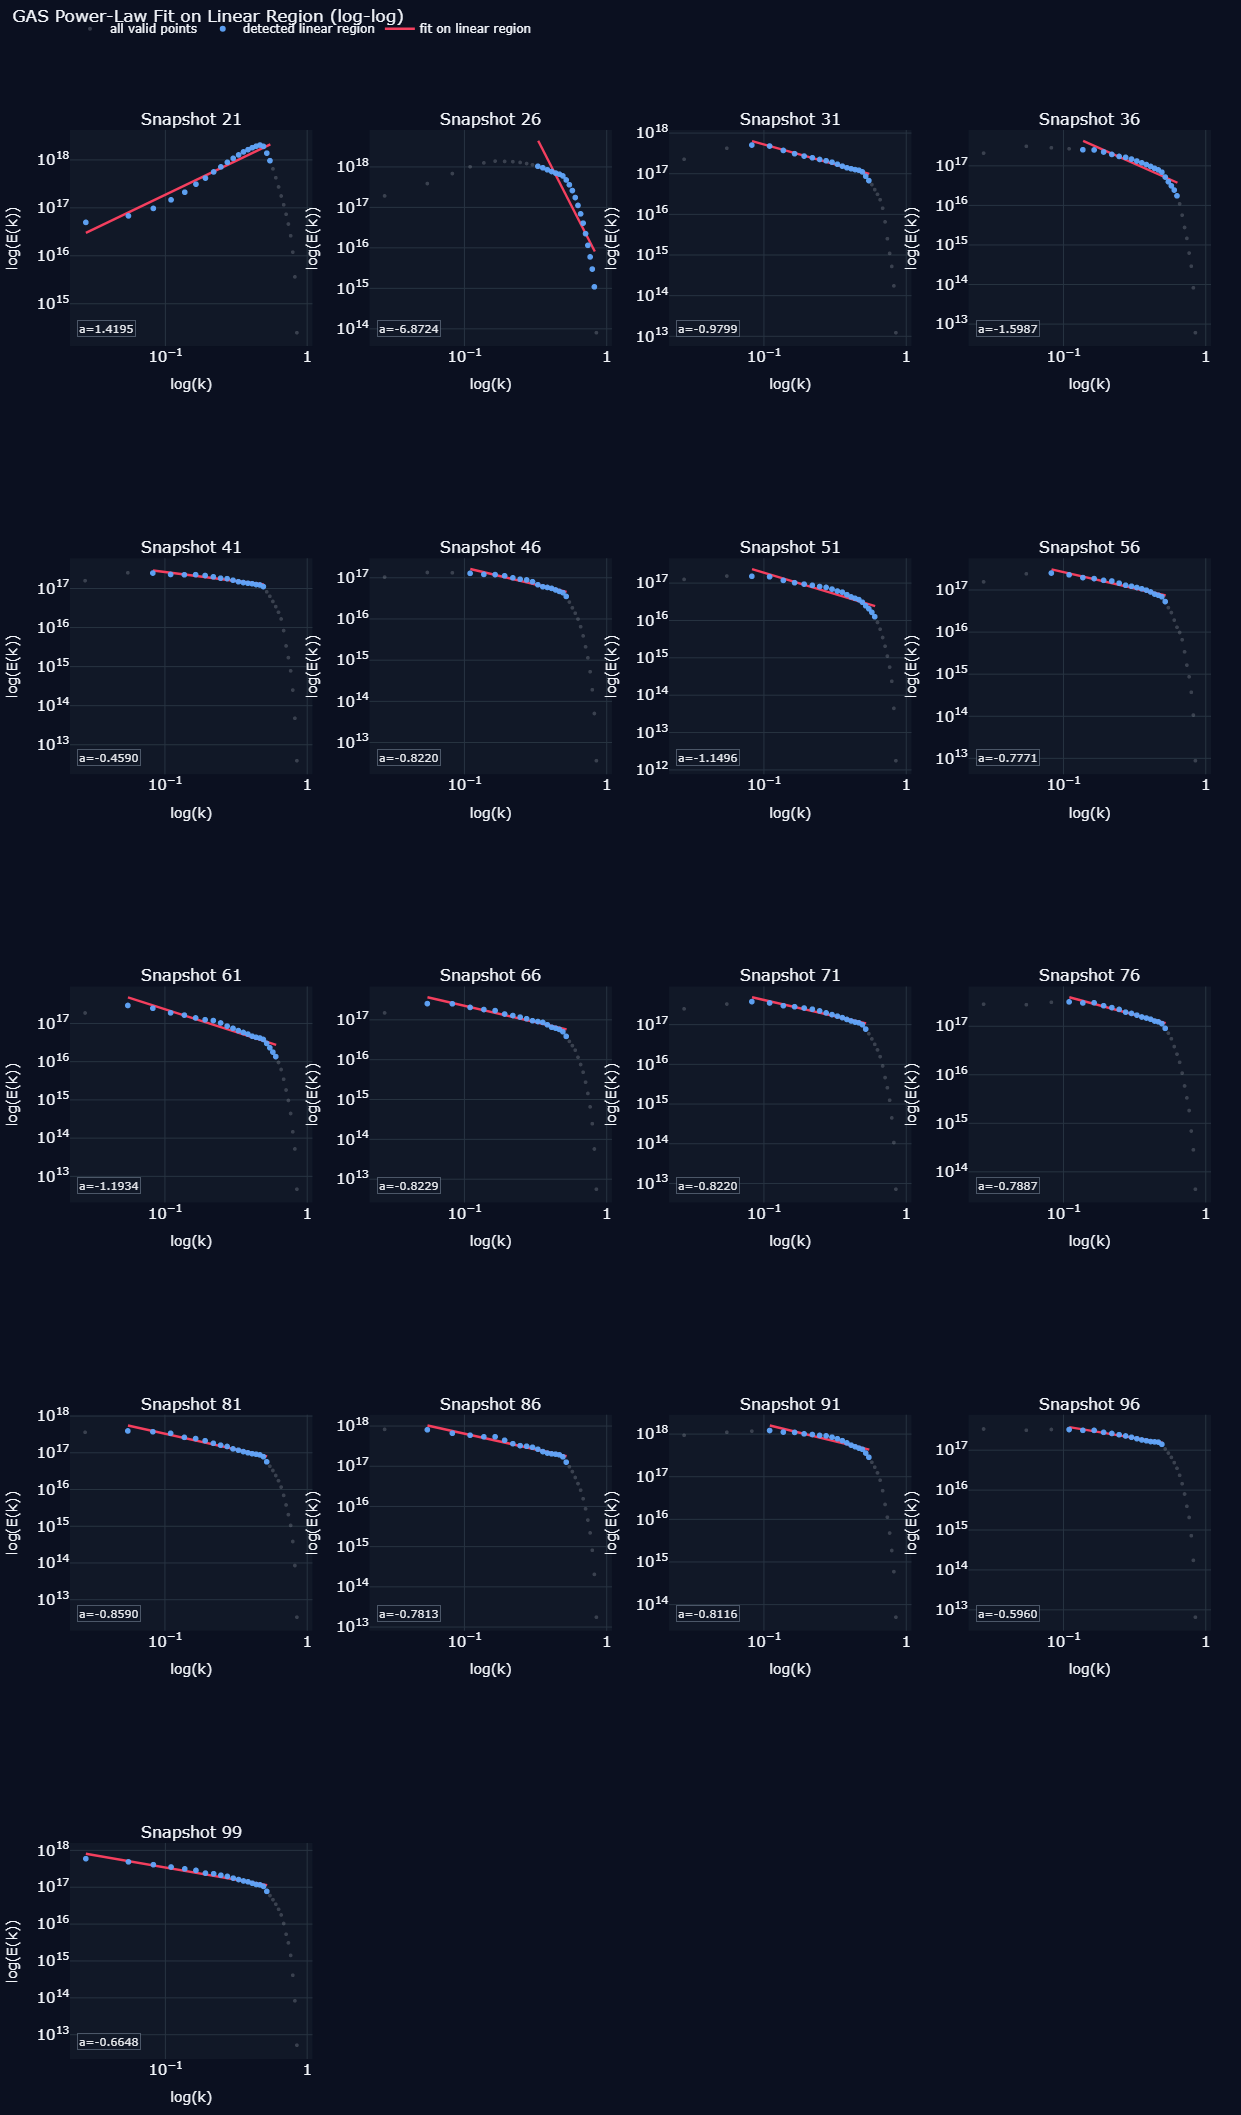

Saved gas fit cache: cache_powerlaw/gas_fit_v1_stride5_Ng128_R200_min5000_n17.pkl
Saved gas figure: plots_powerlaw/gas_powerlaw_linear_region_subplots_plotly.html
Gas spectra cache: cache_powerlaw/gas_spectra_v1_stride5_Ng128_R200_min5000_n17.pkl
Gas fit cache: cache_powerlaw/gas_fit_v1_stride5_Ng128_R200_min5000_n17.pkl
Gas spectra loaded from cache: False


,Snapshot,a,b,exp_b,r2,k_min,k_max,n_points
0,21,1.419515,43.044429,4.942629e+18,0.931813,0.027493,0.549857,20
1,26,-6.872449,35.310325,2.163114e+15,0.812777,0.329914,0.824786,19
2,31,-0.979902,38.546427,5.501744e+16,0.956396,0.082479,0.549857,18
3,36,-1.598689,37.428033,1.797994e+16,0.843418,0.137464,0.632336,19
4,41,-0.458977,39.057867,9.175214e+16,0.915492,0.082479,0.494872,16
5,46,-0.822018,37.818640,2.657216e+16,0.919091,0.109971,0.522365,16
6,51,-1.149640,37.141805,1.350458e+16,0.864434,0.082479,0.604843,20
7,56,-0.777061,38.336650,4.460623e+16,0.926450,0.082479,0.522365,17
8,61,-1.193426,37.259982,1.519863e+16,0.902785,0.054986,0.604843,21
9,66,-0.822918,38.062153,3.389870e+16,0.923962,0.054986,0.522365,18


In [8]:
# GAS: load cached spectra if available, otherwise process and cache

df_gas_spectra, gas_spectra, gas_spectra_cache, gas_loaded = load_or_build_spectra('gas')

# Build/update subplot image; load cached fit dataframe unless FORCE_REFIT=True
gas_img, df_gas_fit, gas_fit_cache = load_or_build_fit('gas', gas_spectra)

print('Saved gas figure:', gas_img)
print('Gas spectra cache:', gas_spectra_cache)
print('Gas fit cache:', gas_fit_cache)
print('Gas spectra loaded from cache:', gas_loaded)

df_gas_fit

Processing dm snapshot 21
Processing dm snapshot 26
Processing dm snapshot 31
Processing dm snapshot 36
Processing dm snapshot 41
Processing dm snapshot 46
Processing dm snapshot 51
Processing dm snapshot 56
Processing dm snapshot 61
Processing dm snapshot 66
Processing dm snapshot 71
Processing dm snapshot 76
Processing dm snapshot 81
Processing dm snapshot 86
Processing dm snapshot 91
Processing dm snapshot 96
Processing dm snapshot 99
Saved dm spectra cache: cache_powerlaw/dm_spectra_v1_stride5_Ng128_R200_min5000_n17.pkl


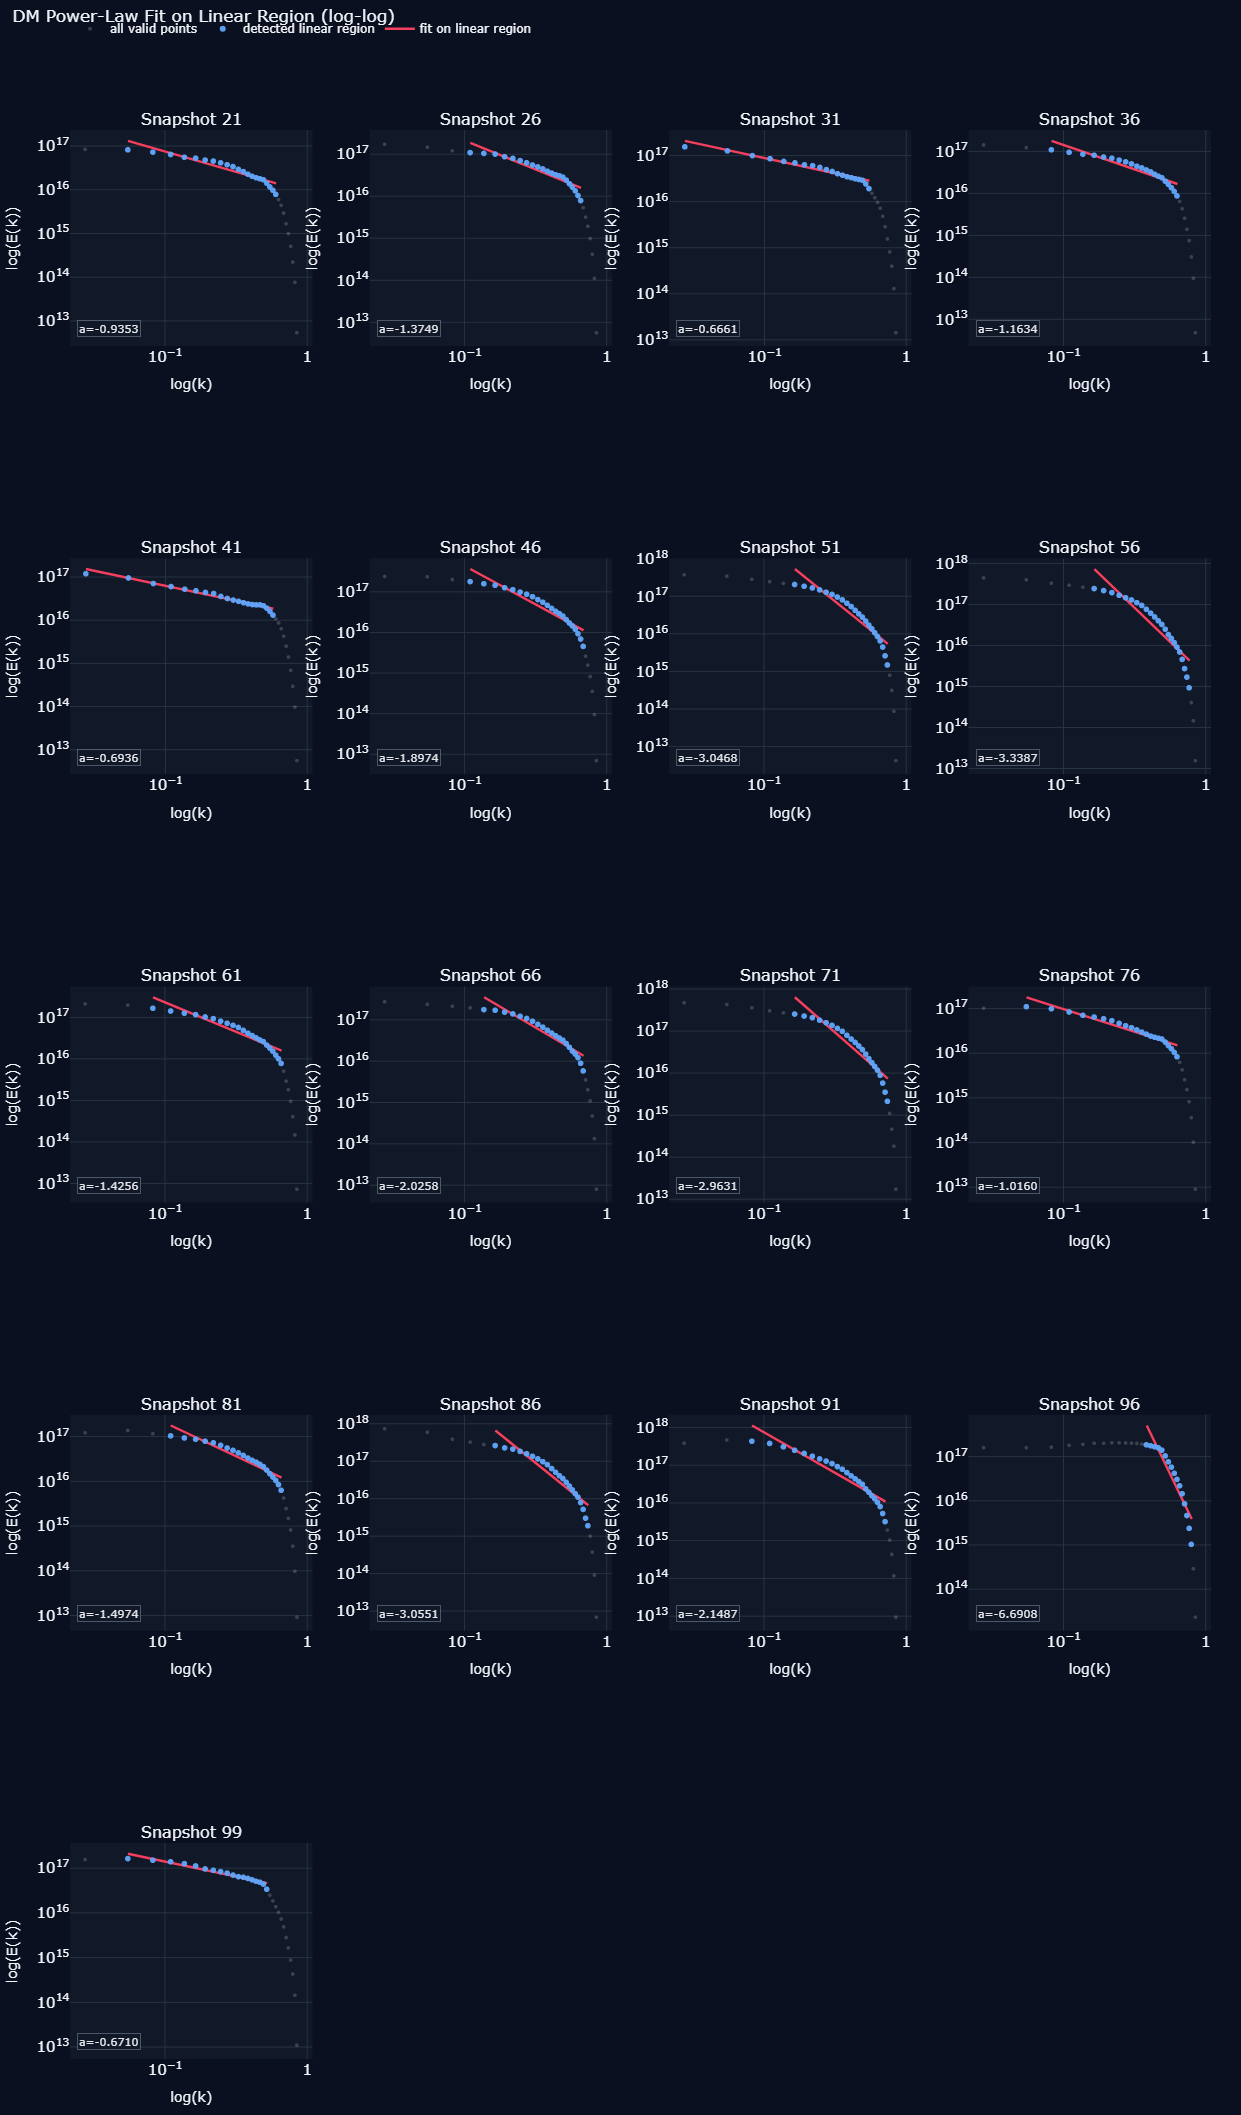

Saved dm fit cache: cache_powerlaw/dm_fit_v1_stride5_Ng128_R200_min5000_n17.pkl
Saved DM figure: plots_powerlaw/dm_powerlaw_linear_region_subplots_plotly.html
DM spectra cache: cache_powerlaw/dm_spectra_v1_stride5_Ng128_R200_min5000_n17.pkl
DM fit cache: cache_powerlaw/dm_fit_v1_stride5_Ng128_R200_min5000_n17.pkl
DM spectra loaded from cache: False


,Snapshot,a,b,exp_b,r2,k_min,k_max,n_points
0,21,-0.935312,36.705096,8.726114e+15,0.871060,0.054986,0.604843,21
1,26,-1.374883,36.728709,8.934611e+15,0.874457,0.109971,0.659829,21
2,31,-0.666060,37.492232,1.917209e+16,0.939683,0.027493,0.549857,20
3,36,-1.163410,36.822483,9.812989e+15,0.861333,0.082479,0.632336,21
4,41,-0.693569,37.075719,1.264096e+16,0.960649,0.027493,0.577350,21
5,46,-1.897434,36.249961,5.535516e+15,0.882025,0.109971,0.687322,22
6,51,-3.046811,35.321256,2.186888e+15,0.872849,0.164957,0.742307,22
7,56,-3.338669,35.124169,1.795697e+15,0.855992,0.164957,0.769800,23
8,61,-1.425607,36.704069,8.717156e+15,0.882832,0.082479,0.659829,22
9,66,-2.025757,36.380392,6.306722e+15,0.893588,0.137464,0.687322,21


In [9]:
# DM: load cached spectra if available, otherwise process and cache

df_dm_spectra, dm_spectra, dm_spectra_cache, dm_loaded = load_or_build_spectra('dm')

# Build/update subplot image; load cached fit dataframe unless FORCE_REFIT=True
dm_img, df_dm_fit, dm_fit_cache = load_or_build_fit('dm', dm_spectra)

print('Saved DM figure:', dm_img)
print('DM spectra cache:', dm_spectra_cache)
print('DM fit cache:', dm_fit_cache)
print('DM spectra loaded from cache:', dm_loaded)

df_dm_fit

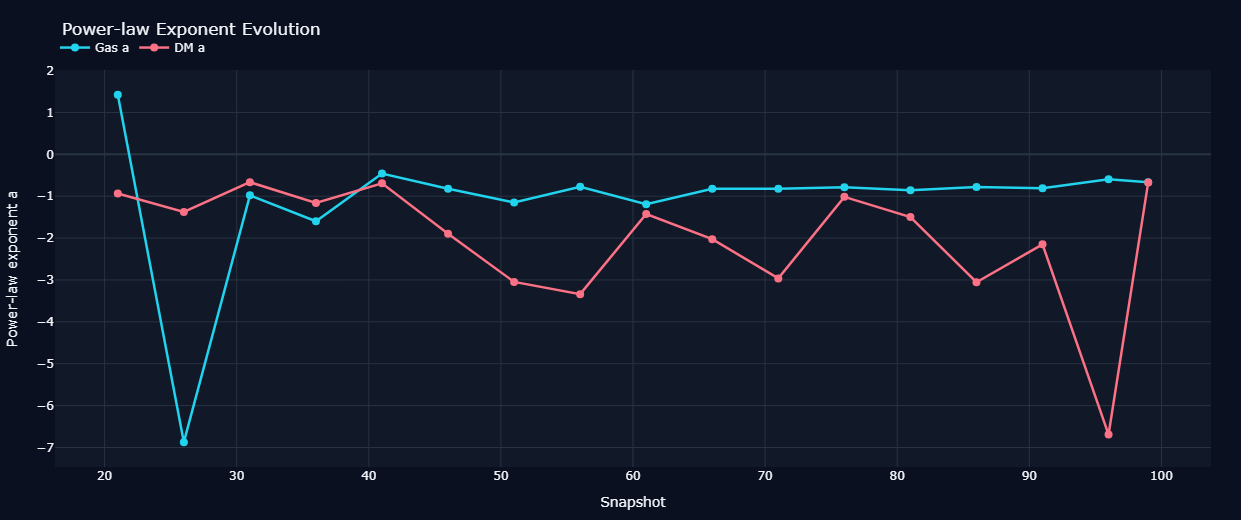

Saved comparison figure: plots_powerlaw/gas_dm_a_comparison_plotly.html


In [10]:
# Optional comparison of fitted a values (Plotly dark theme)
if len(df_gas_fit) > 0 and len(df_dm_fit) > 0:
    df_compare = pd.merge(df_gas_fit, df_dm_fit, on='Snapshot', how='inner', suffixes=('_gas', '_dm'))

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=df_compare['Snapshot'], y=df_compare['a_gas'],
        mode='lines+markers',
        name='Gas a',
        line=dict(color=COLOR_A_GAS, width=2.5),
        marker=dict(size=8)
    ))
    fig.add_trace(go.Scatter(
        x=df_compare['Snapshot'], y=df_compare['a_dm'],
        mode='lines+markers',
        name='DM a',
        line=dict(color=COLOR_A_DM, width=2.5),
        marker=dict(size=8)
    ))

    fig.update_layout(
        title='Power-law Exponent Evolution',
        xaxis_title='Snapshot',
        yaxis_title='Power-law exponent a',
        template='plotly_dark',
        paper_bgcolor=PLOTLY_DARK_BG,
        plot_bgcolor=PLOTLY_PANEL_BG,
        height=520,
        width=980,
        margin=dict(l=50, r=30, t=70, b=45),
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0)
    )

    compare_html = os.path.join(PLOT_DIR, 'gas_dm_a_comparison_plotly.html')
    os.makedirs(PLOT_DIR, exist_ok=True)
    fig.write_html(compare_html, include_plotlyjs='cdn')

    fig.show()
    print('Saved comparison figure:', compare_html)

    df_compare